## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypsa
from pypower.loadcase import loadcase
from scipy.io import loadmat
from pymatreader import read_mat

from pathlib import Path
import os
import sys

sys.path.append("../utils")
from matpower_io import load_matpower_case

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import haversine
import geopandas as gpd

# required imports from pypower to match the original matpower implementation.
# replaces "define constants;" line.
import pypower
from pypower.idx_bus  import PD, BUS_AREA
from pypower.idx_gen  import PG, VG, MBASE, GEN_STATUS, PMAX, PMIN
from pypower.idx_brch import BR_X, RATE_A, PF

# pd.set_option("display.max_colwidth", None)  # Show full text (no truncation)  
# pd.set_option("display.width", 1000)  #

## Set paths

In [2]:
tamu_path = Path("../../../2021TXPowerOutage")
eia_path = tamu_path/"From EIA (Generation, Demand, Demand Forecasts, and Interchange by BA)"
case_path = tamu_path/"bte2k/case_Mar3_5pm.mat"
#case_path = tamu_path/"bte2k/hvdc_upgraded.mat"
gen_path = eia_path/"ERCOT Generation by Source/2021-02-01 to 2021-02-19.csv"
#load_path = "eia_path/BES profiles/BES_demand_Feb2021_v20210224.csv"
load_path = eia_path/"ERCOT Demand by Subregion/2021-02-01 to 2021-02-19.csv"
wind_path = eia_path/"BES profiles/BES_wind_Feb2021_v20210224.csv"
solar_path = eia_path/"BES profiles/BES_solar_Feb2016_v20210224.csv"
hydro_path = eia_path/"BES profiles/BES_hydro_Feb2016_v20210224.csv"
lf_path =  eia_path/"ERCOT Demand, Demand Forecast, and Net Interchange/2021-02-01 to 2020-02-19.csv"
# out = "outage"
out_ng_path = tamu_path/"data/unit_outage/ng_outage.csv"
out_pv_path = tamu_path/"data/unit_outage/pv_outage.csv"
out_coal_path = tamu_path/"data/unit_outage/coal_outage.csv"
gen_county_path = tamu_path/"data/unit_outage/gen_county.csv"
ng_derate_path = tamu_path/"data/unit_outage/ng_derate_fac.csv"

out_path = tamu_path/"data/out_mat.mat"
shed_path = tamu_path/"data/shed_mat.mat"
cap_path = tamu_path/"data/ercotcap_mat.mat"
lcf_path = tamu_path/"data/lf_mat.mat"
cty_outage_pct_path = tamu_path/'data/load_outage/cty_out_pct.csv'
cty_outage_dist_path = tamu_path/'data/load_outage/cty_out_dist.csv'
all_bus_cty_path = tamu_path/'data/load_outage/bus_county.csv'

In [3]:
# create shared index for all timeseries
study_index = pd.date_range("2021-02-01", "2021-02-20", 
                            inclusive='left', 
                            freq='h').tz_localize('US/Central')
study_index

DatetimeIndex(['2021-02-01 00:00:00-06:00', '2021-02-01 01:00:00-06:00',
               '2021-02-01 02:00:00-06:00', '2021-02-01 03:00:00-06:00',
               '2021-02-01 04:00:00-06:00', '2021-02-01 05:00:00-06:00',
               '2021-02-01 06:00:00-06:00', '2021-02-01 07:00:00-06:00',
               '2021-02-01 08:00:00-06:00', '2021-02-01 09:00:00-06:00',
               ...
               '2021-02-19 14:00:00-06:00', '2021-02-19 15:00:00-06:00',
               '2021-02-19 16:00:00-06:00', '2021-02-19 17:00:00-06:00',
               '2021-02-19 18:00:00-06:00', '2021-02-19 19:00:00-06:00',
               '2021-02-19 20:00:00-06:00', '2021-02-19 21:00:00-06:00',
               '2021-02-19 22:00:00-06:00', '2021-02-19 23:00:00-06:00'],
              dtype='datetime64[ns, US/Central]', length=456, freq=None)

## Load data

In [4]:
out_ts = read_mat(out_path)['out_mat']
shed_ts = read_mat(shed_path)['shed_mat']
cap_ts = read_mat(cap_path)['cap_mat']
lcf_ts = read_mat(lcf_path)['lf_mat']

# the original script has the following line, and I'm not sure why...
shed_ts[:312, 2] = np.nan

In [5]:
# this reads the mpc case directly as a dictionary. 
# I may want to use an alternative method.
mpc = read_mat(case_path)['mpc']

In [6]:
# I'm not sure if I need these since I'm not using matpower. 
# Keeping for reference.
if False:
    mpopt = mpoption('pf.nr.max_it', 50)
    mpopt = mpoption(mpopt,'out.all',0)
    mpopt = mpoption(mpopt,'verbose',0)

In [7]:
def read_ercot_csv(path):
    df = pd.read_csv(path)
    date_parser = lambda date: pd.to_datetime(date.replace("CST",""), 
                                              utc=False).tz_localize("US/Central")
    df['datetime'] = df['Timestamp (Hour Ending)'].apply(date_parser)
    df = df.set_index('datetime')
    df.drop(columns=['Timestamp (Hour Ending)','BA Code'], inplace=True)
    return df

def read_county_df(path):
    out_df = pd.read_csv(path, index_col='UTC')
    out_df.index = pd.to_datetime(out_df.index, utc=False).tz_localize('US/Central')

    # requires globally defined "study index"
    out_df = out_df.reindex(study_index).fillna(0)

    return out_df

In [9]:
# Read the data into a Pandas DataFrame
gen_df = read_ercot_csv(gen_path)
lf_df = read_ercot_csv(lf_path)
load_df = read_ercot_csv(load_path)
load_df.columns = [col.replace(" Demand (MWh)",'') for col in load_df.columns]
cty_out_dist_df = pd.read_csv(cty_outage_dist_path,
                             index_col='UTC')
cty_out_dist_df.index = pd.to_datetime(cty_out_dist_df.index, utc=False).tz_localize('US/Central')

# read in a list of buses
bus_df = pd.read_csv(all_bus_cty_path, index_col=0)


## Fill in missing data for `cty_out_dist_df`

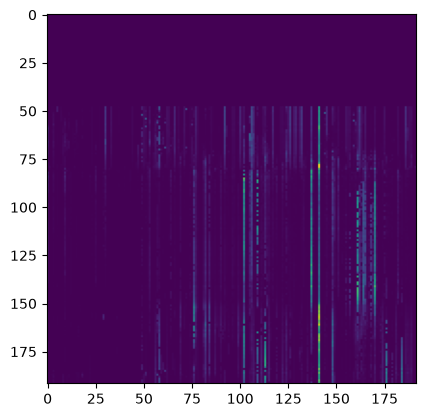

In [10]:
plt.imshow(cty_out_dist_df.values)

In [11]:
outage_ctys = cty_out_dist_df.loc[:,cty_out_dist_df.tail(3).sum(axis=0)>0].columns

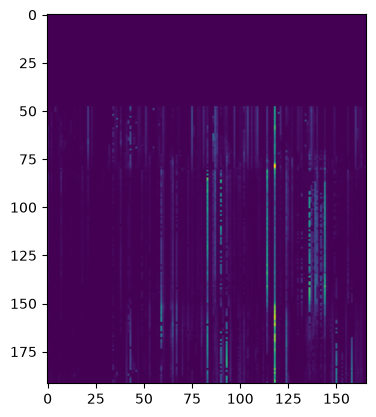

In [12]:
plt.imshow(cty_out_dist_df.loc[:, outage_ctys])

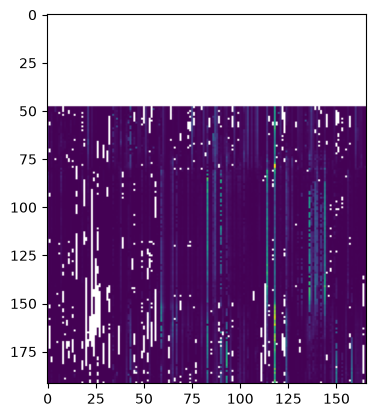

In [13]:
plt.imshow(cty_out_dist_df.loc[:, outage_ctys].replace(0, np.nan))

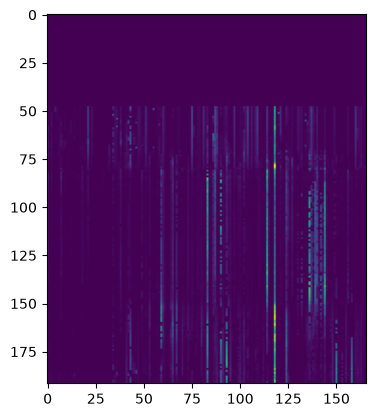

In [14]:
plt.imshow(cty_out_dist_df.loc[:, outage_ctys].replace(0, np.nan).ffill().fillna(0))

In [15]:
# fill in missing data
cty_out_dist_df.loc[:, outage_ctys] = cty_out_dist_df.loc[:, outage_ctys].replace(0, np.nan).ffill().fillna(0)

In [16]:
# normalize each row
cty_out_dist_df = cty_out_dist_df.div(cty_out_dist_df.sum(axis=1),axis=0).fillna(0)

<Axes: xlabel='UTC'>

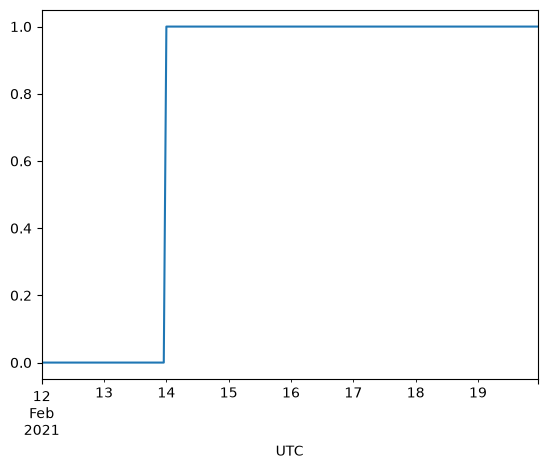

In [17]:
cty_out_dist_df.sum(axis=1).plot()

In [18]:
cty_out_dist_df = cty_out_dist_df.reindex(study_index).fillna(0)

## Create mapping of county outages to bus outages.

In [19]:
bus_county_num = len(cty_out_dist_df.columns)

In [20]:
header_map = {
pypower.idx_bus.BASE_KV:'BASE_KV',
pypower.idx_bus.BS:'BS',
pypower.idx_bus.BUS_AREA:'BUS_AREA',
pypower.idx_bus.BUS_I:'BUS_I',
pypower.idx_bus.BUS_TYPE:'BUS_TYPE',
pypower.idx_bus.GS:'GS',
pypower.idx_bus.LAM_P:'LAM_P',
pypower.idx_bus.LAM_Q:'LAM_Q',
pypower.idx_bus.MU_VMAX:'MU_VMAX',
pypower.idx_bus.MU_VMIN:'MU_VMIN',
# pypower.idx_bus.NONE:'NONE',
pypower.idx_bus.PD:'PD',
# pypower.idx_bus.PQ:'PQ',
# pypower.idx_bus.PV:'PV',
# pypower.idx_bus.QD:'QD',
pypower.idx_bus.REF:'REF',
pypower.idx_bus.VA:'VA',
pypower.idx_bus.VM:'VM',
pypower.idx_bus.VMAX:'VMAX',
pypower.idx_bus.VMIN:'VMIN',
pypower.idx_bus.ZONE:'ZONE'
}

In [21]:
mpc_bus_df = pd.DataFrame(mpc['bus']).rename(columns=header_map)
mpc_bus_df['BUS_I'] = mpc_bus_df['BUS_I'].astype(int)

In [22]:
mpc_bus_df

,BUS_I,BUS_TYPE,PD,REF,GS,BS,BUS_AREA,VM,VA,BASE_KV,ZONE,VMAX,VMIN,LAM_P,LAM_Q,MU_VMAX,MU_VMIN
0,3001001,1.0,20.78,5.89,0.0,0.00,301.0,0.998372,-22.3462,115.0,9.0,1.1,0.9,0.0,0.0,0.0,0.0
1,3001002,1.0,15.41,4.37,0.0,0.00,301.0,1.022910,-17.8585,115.0,9.0,1.1,0.9,0.0,0.0,0.0,0.0
2,3001003,1.0,0.00,0.00,0.0,0.00,301.0,1.014100,-17.5032,115.0,9.0,1.1,0.9,0.0,0.0,0.0,0.0
3,3001004,2.0,0.00,0.00,0.0,0.00,301.0,1.020050,-19.3247,230.0,9.0,1.1,0.9,0.0,0.0,0.0,0.0
4,3001005,1.0,0.00,0.00,0.0,0.00,301.0,1.012380,-15.9276,115.0,9.0,1.1,0.9,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3008156,1.0,0.00,0.00,0.0,0.00,308.0,1.026110,-46.1097,230.0,7.0,1.1,0.9,0.0,0.0,0.0,0.0
1996,3008157,1.0,0.00,0.00,0.0,0.00,308.0,1.028080,-50.0113,115.0,7.0,1.1,0.9,0.0,0.0,0.0,0.0
1997,3008158,2.0,0.00,0.00,0.0,0.00,308.0,1.026500,-39.4672,500.0,7.0,1.1,0.9,0.0,0.0,0.0,0.0
1998,3008159,1.0,0.00,0.00,0.0,125.36,308.0,1.030000,-42.6388,230.0,7.0,1.1,0.9,0.0,0.0,0.0,0.0


In [23]:
bus_out_dist = np.zeros((len(cty_out_dist_df), len(bus_df)))
for i, curr_cty in enumerate(cty_out_dist_df.columns):
    bus_curr_cty = bus_df['0']==curr_cty
    ratio = mpc_bus_df.loc[bus_curr_cty, "PD"].div(mpc_bus_df.loc[bus_curr_cty, "PD"].sum(),axis=0)
    bus_out_dist[:, bus_curr_cty] = np.outer(cty_out_dist_df.loc[:, curr_cty].to_numpy(), ratio)

In [24]:
bus_out_dist = np.nan_to_num(bus_out_dist, nan=0)

## Create area-level outage distributions

In [25]:
n_areas = len(mpc_bus_df['BUS_AREA'].unique())
n_buses = len(bus_df)
area_out_dist = np.zeros((len(cty_out_dist_df), n_areas))
for a in range(n_buses):
    ar = int(mpc_bus_df.at[a, 'BUS_AREA'] % 300)-1 # subtract 1 for indexing
    area_out_dist[:, ar] += bus_out_dist[:, a]

# area_out_dist = np.divide(area_out_dist, np.sum(area_out_dist,axis=1),axis=0)
area_out_dist = area_out_dist / np.sum(area_out_dist,axis=1, keepdims=True)
area_out_dist = np.nan_to_num(area_out_dist, nan=0)

C:\Users\SDotson\AppData\Local\Temp\ipykernel_42792\1179609285.py:9: RuntimeWarning: invalid value encountered in divide
  area_out_dist = area_out_dist / np.sum(area_out_dist,axis=1, keepdims=True)


## Outage Data By County

In [26]:
out_ng_df = read_county_df(out_ng_path)
out_pv_df = read_county_df(out_pv_path)
out_coal_df = read_county_df(out_coal_path)
ng_derate_df = read_county_df(ng_derate_path)

county_list = ng_derate_df.columns
county_num = len(county_list)


In [27]:
gen_county_df = pd.read_csv(gen_county_path, index_col=0)

In [28]:
lf_df = lf_df.reindex(study_index)
gen_df = gen_df.reindex(study_index)
load_df = load_df.reindex(study_index)

In [29]:
dcnet_ts = lf_df.iloc[:, 3]

In [30]:
# per the code documentation, they remove the first 6 rows which means the authors knew/believed
# that this dataset was actually in UTC.
wind_ts_df = pd.read_csv(wind_path, index_col='UTC')[6:]
wind_ts_df.index = pd.to_datetime(wind_ts_df.index, utc=True).tz_convert('US/Central')

In [31]:
# read in representative solar and wind timeseries
# the original data are from 2016 and will be rescaled according
# to EIA actuals.
hydro_ts_df = pd.read_csv(hydro_path, index_col='CST')
hydro_ts_df = hydro_ts_df.reset_index(drop=True)
hydro_ts_df = hydro_ts_df.reindex(range(len(study_index)))
hydro_ts_df = hydro_ts_df.set_index(study_index)

solar_ts_df = pd.read_csv(solar_path, index_col='CST')
solar_ts_df = solar_ts_df.reset_index(drop=True)
solar_ts_df = solar_ts_df.reindex(range(len(study_index)))
solar_ts_df = solar_ts_df.set_index(study_index)

In [32]:
genmix_header = ["wind", "solar", "hydro", "other", "ng", "coal", "nuclear"]

coal_ind = np.where(np.asarray(mpc['genfuel'])=='coal')[0]
pv_ind = np.where(np.asarray(mpc['genfuel'])=='solar')[0]
hydro_ind = np.where(np.asarray(mpc['genfuel'])=='hydro')[0]
ng_ind = np.where(np.asarray(mpc['genfuel'])=='ng')[0]
nuke_ind = np.where(np.asarray(mpc['genfuel'])=='nuclear')[0]
wind_ind = np.where(np.asarray(mpc['genfuel'])=='wind')[0]

In [33]:
area_mpc = ["FW", "N", "W", "S", "NC", "SC", "C", "E"]
col_names = ["Far West", "North", "West", "South", "North Central", "South Central", "Coast", "East"]
zone_header_map = dict(zip(col_names, area_mpc))

The load df has 433 rows, which is fewer than 456. But if I reindex with the study index
the load is padded with NaNs at the end. The original dataset had a datetime column called "CST,"
which I treated as accurate. But it seems like some of the other datasets with UTC columns were
incorrectly labeled "UTC" -- or at least they're being treated that way. Just something to be
wary of.

I just checked the original matlab code, and they actually removed the first 24 hours of the dataset.
Reindexing by the study index does the same thing, but pads the end. As long as I drop the NaN values
at the end, I should have the same shape and properly aligned data.

In [34]:
load_rearranged = load_df.rename(columns=zone_header_map)[area_mpc].reindex(study_index).dropna(axis=0)

In [35]:
ect_shed_ttl = lcf_ts[:409, :] - load_rearranged.values
ect_shed = np.nan_to_num(ect_shed_ttl / ect_shed_ttl.sum(axis=1, keepdims=True), nan=0)

C:\Users\SDotson\AppData\Local\Temp\ipykernel_42792\217546379.py:2: RuntimeWarning: invalid value encountered in divide
  ect_shed = np.nan_to_num(ect_shed_ttl / ect_shed_ttl.sum(axis=1, keepdims=True), nan=0)


## Generation data

In [36]:
gen_header_map = {
pypower.idx_gen.APF:"APF",
pypower.idx_gen.GEN_BUS:"GEN_BUS",
pypower.idx_gen.GEN_STATUS:"GEN_STATUS",
pypower.idx_gen.MBASE:"MBASE",
pypower.idx_gen.MU_PMAX:"MU_PMAX",
pypower.idx_gen.MU_PMIN:"MU_PMIN",
pypower.idx_gen.MU_QMAX:"MU_QMAX",
pypower.idx_gen.MU_QMIN:"MU_QMIN",
pypower.idx_gen.PC1:"PC1",
pypower.idx_gen.PC2:"PC2",
pypower.idx_gen.PG:"PG",
pypower.idx_gen.PMAX:"PMAX",
pypower.idx_gen.PMIN:"PMIN",
pypower.idx_gen.QC1MAX:"QC1MAX",
pypower.idx_gen.QC1MIN:"QC1MIN",
pypower.idx_gen.QC2MAX:"QC2MAX",
pypower.idx_gen.QC2MIN:"QC2MIN",
pypower.idx_gen.QG:"QG",
pypower.idx_gen.QMAX:"QMAX",
pypower.idx_gen.QMIN:"QMIN",
pypower.idx_gen.RAMP_10:"RAMP_10",
pypower.idx_gen.RAMP_30:"RAMP_30",
pypower.idx_gen.RAMP_AGC:"RAMP_AGC",
pypower.idx_gen.RAMP_Q:"RAMP_Q",
pypower.idx_gen.VG:"VG",
}

In [37]:
mpc_gen_df = pd.DataFrame(mpc['gen']).rename(columns=gen_header_map)
mpc_gen_df

,GEN_BUS,PG,QG,QMAX,QMIN,VG,MBASE,GEN_STATUS,PMAX,PMIN,...,QC2MAX,RAMP_AGC,RAMP_10,RAMP_30,RAMP_Q,APF,MU_PMAX,MU_PMIN,MU_QMAX,MU_QMIN
0,3001004.0,158.25,-30.38,44.94,-30.38,1.01,253.20,1.0,238.289072,0.0,...,0.0,0.0,0.0,inf,0.0,211.0,0.0,0.0,0.0,0.0
1,3001006.0,25.73,-4.94,7.31,-4.94,1.00,41.16,1.0,38.736091,0.0,...,0.0,0.0,0.0,inf,0.0,34.3,0.0,0.0,0.0,0.0
2,3001009.0,61.87,-11.88,17.57,-11.88,1.00,99.00,1.0,93.169898,0.0,...,0.0,0.0,0.0,inf,0.0,82.5,0.0,0.0,0.0,0.0
3,3001011.0,9.99,0.00,0.00,0.00,1.00,12.00,1.0,16.497354,0.0,...,0.0,0.0,0.0,inf,0.0,10.0,0.0,0.0,0.0,0.0
4,3001021.0,149.63,-28.73,42.49,-28.73,1.00,239.40,1.0,225.301753,0.0,...,0.0,0.0,0.0,inf,0.0,199.5,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601,3002079.0,0.00,0.00,0.00,0.00,0.00,0.00,1.0,454.000000,0.0,...,0.0,0.0,0.0,inf,0.0,0.0,0.0,0.0,0.0,0.0
602,3002130.0,0.00,0.00,0.00,0.00,0.00,0.00,1.0,189.000000,0.0,...,0.0,0.0,0.0,inf,0.0,0.0,0.0,0.0,0.0,0.0
603,3004197.0,0.00,0.00,0.00,0.00,0.00,0.00,1.0,17.300000,0.0,...,0.0,0.0,0.0,inf,0.0,0.0,0.0,0.0,0.0,0.0
604,3005377.0,0.00,0.00,0.00,0.00,0.00,0.00,1.0,81.800000,0.0,...,0.0,0.0,0.0,inf,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
# modify base case gen
mpc['gen'][:, GEN_STATUS] = 1
# change the generator cost to linear (removing c2 in mpc.gencost)
mpc['gen'][554, VG] = 1.02 # subtract 1 from the matlab version 

In [39]:
# save basic thermal capacity
gen_base = mpc['gen'][:, PMAX]
gen_min = mpc['gen'][:, PMIN]
coal_base = mpc['gen'][coal_ind,PMAX]
coal_base[coal_base==0] = 1
coal_min = mpc['gen'][coal_ind,PMIN]
ng_base = mpc['gen'][ng_ind,PMAX]
ng_base[ng_base==0] = 1
ng_min = mpc['gen'][ng_ind,PMIN]
nuke_base = mpc['gen'][378, PMAX] # subtract 1 from the matlab version
nuke_min = mpc['gen'][378, PMIN] # subtract 1 from the matlab version
wind_base = mpc['gen'][wind_ind,MBASE]


In [40]:
gen_area = np.floor((mpc['gen'][:,0] % 3000000)/1e3).astype(int)

In [41]:
out_ts = np.nan_to_num(out_ts, nan=0)

In [42]:
# modify DC tie flow
dcbus_ind = np.asarray([145, 1966])
dc_ratio = np.asarray([0.25, 0.75])

In [43]:
# change counterfacturals
eta = 1; # 0 - SIMULATED shed; 1 - ERCOT shed
# winterization in MW for each area
weatherization_mw_ng = np.asarray([5000, 1000, 1500, 1500, 3500, 4000, 1500, 2500])*0
weatherization_mw_wind = np.asarray([1000, 2000, 500, 500, 000, 00, 00, 00])*0
weatherization_mw_coal = np.asarray([0, 0, 0, 000, 2500, 500, 000, 1500])*0
weatherization_nuke = 0


# area total winterized 
weatherization_pct_ng_area = np.zeros((1, 8))
weatherization_pct_wind_area = np.zeros((1, 8))
weatherization_pct_coal_area = np.zeros((1, 8))

ng_area_base = np.zeros((1, 8))
wind_area_base = np.zeros((1, 8))
coal_area_base = np.zeros((1, 8))

In [46]:
# compute percentage of winterization for each area
for i in range(n_areas):
    area_ng_ind = np.intersect1d(np.where(gen_area==i+1)[0], ng_ind)
    area_wind_ind = np.intersect1d(np.where(gen_area==i+1)[0], wind_ind)
    area_coal_ind = np.intersect1d(np.where(gen_area==i+1)[0], coal_ind)

    area_ng_total = sum(gen_base[area_ng_ind])
    area_wind_total = sum(mpc_gen_df.loc[area_wind_ind,'MBASE'])
    area_coal_total = sum(gen_base[area_coal_ind])
    
    ng_area_base[0, i] = area_ng_total
    wind_area_base[0, i] = area_wind_total
    coal_area_base[0, i] = area_coal_total
    
    weatherization_pct_ng_area[0, i] = min(weatherization_mw_ng[i] / sum(gen_base[ng_ind]), 1) # pct of winterized cap in area
    weatherization_pct_wind_area[0, i] = min(weatherization_mw_wind[i] / sum(mpc_gen_df.loc[wind_ind, 'MBASE']), 1)
    weatherization_pct_coal_area[0, i] = min(weatherization_mw_coal[i] / sum(gen_base[coal_ind]), 1)

weatherization_pct_coal_area[0, 1-1:3] = 0 # subtracted 1 from matlab version indices to get correct values.
weatherization_pct_wind_area[0, 6-1:8] = 0 # subtracted 1 from matlab version indices to get correct values.

In [50]:
gen_num = mpc['gen'].shape[0]
weatherization_vec = np.zeros((gen_num, 1))
for i in range(gen_num):
    if mpc['genfuel'][i] == 'ng':
        weatherization_vec[i] = weatherization_pct_ng_area.T[gen_area[i]-1] # minus 1 for python indexing
    elif mpc['genfuel'][i] == 'wind':
        weatherization_vec[i] = weatherization_pct_wind_area.T[gen_area[i]-1] # minus 1 for python indexing
    elif mpc['genfuel'][i] == 'coal':    
        weatherization_vec[i] = weatherization_pct_coal_area.T[gen_area[i]-1] # minus 1 for python indexing
    else:
        weatherization_vec[i] = 0

In [51]:
# hvdc
dc_enable = 0
dc_ttl = 4000
newdc_cap = np.asarray([0.5, 0.5]) * dc_ttl
newdcbus_ind = np.asarray([272, 1934])


# storage
store_cap = 0 # 5GW

# DR
dr_cap = 0 # 3GW

# merge line upgrades
d3mpc = read_mat(tamu_path/'bte2k/hvdc_upgraded.mat')['mpc_orig']

In [52]:
mpc['branch'][:,RATE_A] = np.maximum(mpc['branch'][:,RATE_A], d3mpc['branch'][d3mpc['branch'][:, 0] > 3000000,RATE_A])
mpc['branch'][:,BR_X] = np.minimum(mpc['branch'][:,BR_X], d3mpc['branch'][d3mpc['branch'][:, 0] > 3000000,BR_X])

In [ ]:
lf_df = lf_df.reindex(study_index)
gen_df = gen_df.reindex(study_index)
load_df = load_df.reindex(study_index)

<Axes: >

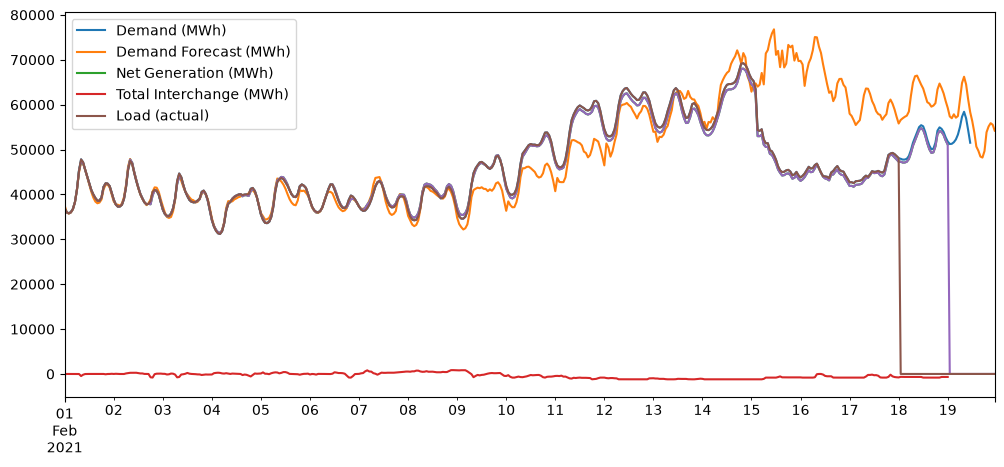

In [53]:
fig, ax = plt.subplots(figsize=(12,5))
lf_df.reindex(study_index).plot(ax=ax)
gen_df.reindex(study_index).sum(axis=1).plot(ax=ax)
load_df.reindex(study_index).sum(axis=1).to_frame().rename({0:'Load (actual)'},axis=1).plot(ax=ax)